In [72]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
from torch.nn import CrossEntropyLoss
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)

# **Load Data**

In [73]:
df = pd.read_csv('/kaggle/input/datasets/imuhbayu/dataset-berita-ihsg-cnbc-untuk-text-mining/cnbc_ihsg_articles_clean.csv')
df

,url,title,title_clean,author,publish_date,keywords,keywords_clean,content,content_clean,text,text_length
0,https://www.cnbcindonesia.com/market/202601281...,"Mengenal MSCI, Lembaga yang 'Ditakuti' Pasar d...",mengenal msci lembaga yang ditakuti pasar dan ...,Mentari Puspadini,2026-01-28 13:35:00,"msci, morgan stanley capital international, ih...",msci morgan stanley capital international ihsg...,"Jakarta,CNBC Indonesia - Morgan Stanley Capita...",jakarta cnbc indonesia morgan stanley capital ...,mengenal msci lembaga yang ditakuti pasar dan ...,5103
1,https://www.cnbcindonesia.com/market/202601281...,"Potret IHSG Ambruk 7% Lebih, Seluruh Sektor Me...",potret ihsg ambruk 7 lebih seluruh sektor memerah,CNBC Indonesia/Muhammad Sabki,2026-01-28 13:15:00,"ihsg, bursa, saham, investasi, bursa efek indo...",ihsg bursa saham investasi bursa efek indonesi...,Suasana layar digital pergerakan harga saham d...,suasana layar digital pergerakan harga saham d...,potret ihsg ambruk 7 lebih seluruh sektor meme...,1666
2,https://www.cnbcindonesia.com/market/202601281...,"BBCA Makin Dijauhi Asing, Net Sell Sesi 1 Temb...",bbca makin dijauhi asing net sell sesi 1 tembu...,mkh,2026-01-28 13:44:00,"net foreign sell, ihsg, investor asing, saham ...",net foreign sell ihsg investor asing saham ind...,"Jakarta, CNBC Indonesia — Di tengah tekanan te...",jakarta cnbc indonesia di tengah tekanan terha...,bbca makin dijauhi asing net sell sesi 1 tembu...,3858
3,https://www.cnbcindonesia.com/market/202601281...,"Alasan IHSG Anjlok 8%, Dampak Trading Halt Hin...",alasan ihsg anjlok 8 dampak trading halt hingg...,Romys Binekasri & Mentari Puspadini & Zefanya ...,2026-01-28 13:52:00,"trading halt, ihsg, msci, bursa efek indonesia...",trading halt ihsg msci bursa efek indonesia in...,"Jakarta, CNBC Indonesia - Indeks Harga Saham G...",jakarta cnbc indonesia indeks harga saham gabu...,alasan ihsg anjlok 8 dampak trading halt hingg...,8278
4,https://www.cnbcindonesia.com/market/202601281...,Breaking: Trading Halt! IHSG Ambruk 8% Gara-Ga...,breaking trading halt ihsg ambruk 8 gara gara ...,Romys Binekasri,2026-01-28 13:47:00,"trading halt, ihsg, msci, bursa efek indonesia...",trading halt ihsg msci bursa efek indonesia pa...,"Jakarta, CNBC Indonesia — Bursa Efek Indonesia...",jakarta cnbc indonesia bursa efek indonesia be...,breaking trading halt ihsg ambruk 8 gara gara ...,2048
...,...,...,...,...,...,...,...,...,...,...,...
551,https://www.cnbcindonesia.com/research/2026033...,Trump Ngamuk! Pemerintah Akan Umumkan Kebijaka...,trump ngamuk pemerintah akan umumkan kebijakan...,Elvan Widyatama,2026-03-31 06:20:00,"newsletter, pasar keuangan, ihsg, rupiah, obli...",newsletter pasar keuangan ihsg rupiah obligasi...,"Jakarta, CNBC Indonesia - Pasar keuangan RI ma...",jakarta cnbc indonesia pasar keuangan ri mayor...,trump ngamuk pemerintah akan umumkan kebijakan...,19271
552,https://www.cnbcindonesia.com/research/2026033...,"IHSG Paling Murah Se-Asia, Saatnya Serok atau ...",ihsg paling murah se asia saatnya serok atau t...,saw,2026-03-31 07:32:00,"ihsg, valuasi saham, investasi, pasar saham in...",ihsg valuasi saham investasi pasar saham indon...,"Jakarta, CNBC Indonesia - Indeks Harga Saham G...",jakarta cnbc indonesia indeks harga saham gabu...,ihsg paling murah se asia saatnya serok atau t...,4991
553,https://www.cnbcindonesia.com/research/2026033...,Modal IHSG-Rupiah Biar Kuat Lagi: BBM Tak Naik...,modal ihsg rupiah biar kuat lagi bbm tak naik ...,Elvan Widyatama,2026-04-01 06:21:00,"newsletter, pasar keuangan, ihsg, rupiah, obli...",newsletter pasar keuangan ihsg rupiah obligasi...,"Jakarta, CNBC Indonesia - Pasar keuangan Tanah...",jakarta cnbc indonesia pasar keuangan tanah ai...,modal ihsg rupiah biar kuat lagi bbm tak naik ...,19346
554,https://www.cnbcindonesia.com/research/2026040...,"April Jadi Bulan Krusial IHSG, Ini Tanggal Ker...",april jadi bulan krusial ihsg ini tanggal kera...,saw,2026-04-01 08:50:00,"bursa efek indonesia, msci, ftse russell, pasa.

# **EDA dan Preprocessing**

## **Data Structure Checking** 

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             556 non-null    object
 1   title           556 non-null    object
 2   title_clean     556 non-null    object
 3   author          556 non-null    object
 4   publish_date    556 non-null    object
 5   keywords        556 non-null    object
 6   keywords_clean  556 non-null    object
 7   content         556 non-null    object
 8   content_clean   556 non-null    object
 9   text            556 non-null    object
 10  text_length     556 non-null    int64 
dtypes: int64(1), object(10)
memory usage: 47.9+ KB


## **Descriptive Statistics Summary** 

In [75]:
df.describe()

,text_length
count,556.000000
mean,3880.291367
std,4325.954320
min,246.000000
25%,1805.000000
50%,2763.000000
75%,3815.750000
max,23494.000000


In [76]:
df['title_clean'].nunique()

550

## **Drop Unnecessary Columns** 

In [77]:
df.drop(labels=['url', 'title', 'keywords', 'keywords_clean', 'text_length', 'content'], axis=1, inplace=True)

## **Identify Duplicate Data**  

In [78]:
df['title_clean'].duplicated().sum()

np.int64(6)

In [79]:
df[df['title_clean'].duplicated(keep=False)].sort_values('title_clean')

,title_clean,author,publish_date,content_clean,text
188,breaking news ihsg anjlok 1,mkh,2026-02-13 09:22:00,jakarta cnbc indonesia indeks harga saham gabu...,breaking news ihsg anjlok 1 jakarta cnbc indon...
382,breaking news ihsg anjlok 1,mkh,2026-03-26 10:23:00,jakarta cnbc indonesia indeks harga saham gabu...,breaking news ihsg anjlok 1 jakarta cnbc indon...
286,breaking news ihsg turun 5,mkh,2026-03-04 14:10:00,jakarta cnbc indonesia indeks harga saham gabu...,breaking news ihsg turun 5 jakarta cnbc indone...
309,breaking news ihsg turun 5,mkh,2026-03-09 09:13:00,jakarta cnbc indonesia koreksi indeks harga sa...,breaking news ihsg turun 5 jakarta cnbc indone...
110,ihsg masih volatil deretan saham ini menarik b...,Unknown,2026-02-03 08:47:00,jakarta cnbc indonesia indeks harga saham gabu...,ihsg masih volatil deretan saham ini menarik b...
209,ihsg masih volatil deretan saham ini menarik b...,Unknown,2026-02-20 08:43:00,jakarta cnbc indonesia indeks harga saham gabu...,ihsg masih volatil deretan saham ini menarik b...
230,ihsg masih volatil deretan saham ini menarik b...,Unknown,2026-02-25 08:50:00,jakarta cnbc indonesia indeks harga saham gabu...,ihsg masih volatil deretan saham ini menarik b...
389,ihsg masih volatil deretan saham ini menarik b...,Unknown,2026-03-27 09:09:00,jakarta cnbc indonesia indeks harga saham gabu...,ihsg masih volatil deretan saham ini menarik b...
50,sejarah bicara ihsg selalu bangkit cepat setel...,CNBC Indonesia TV,2026-01-29 18:00:00,jakarta cnbc indonesia badai pasti berlalu sat...,sejarah bicara ihsg selalu bangkit cepat setel...
448,sejarah bicara ihsg selalu bangkit cepat setel...,Susi Setiawati,2026-01-29 08:35:00,jakarta cnbc indonesia badai pasti berlalu sat...,sejarah bicara ihsg selalu bangkit cepat setel...


In [80]:
df = df.drop_duplicates(subset=['title_clean'], keep='first')
df.shape

(550, 5)

## **Identify Missing Values**  

In [81]:
df['title_clean'].isnull().sum()

np.int64(0)

## **Convert Publish Date to Datetime**

In [82]:
df.loc[:, 'publish_date'] = pd.to_datetime(df['publish_date']).dt.normalize()
print(df['publish_date'].dtypes)

object


## **The First and The Latest Publish Date** 

In [83]:
df['publish_date'].min()

Timestamp('2026-01-28 00:00:00')

In [84]:
df['publish_date'].max()

Timestamp('2026-04-02 00:00:00')

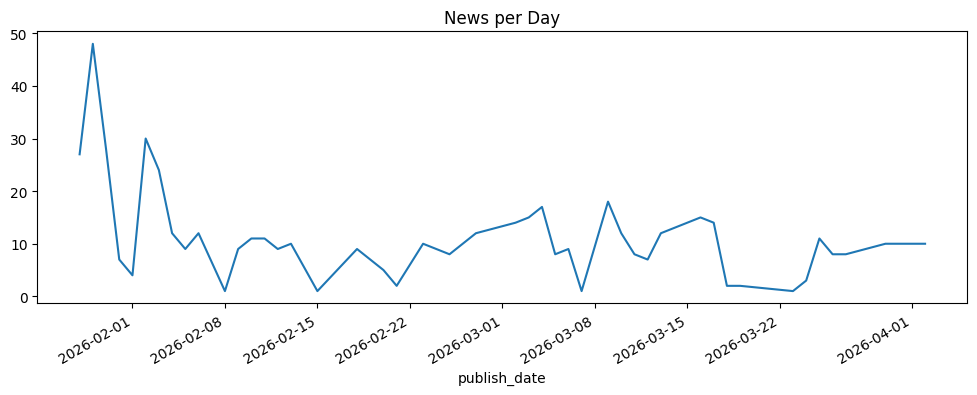

In [85]:
df.groupby('publish_date').size().plot(kind='line', figsize=(12,4), title='News per Day')
plt.show()

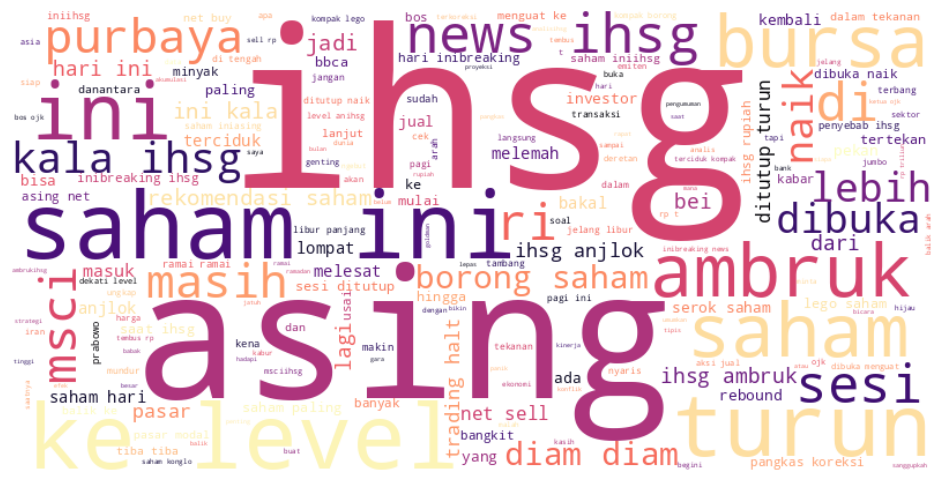

In [86]:
all_text = ''.join(df['title_clean'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## **Auto-Labeling with IndoBERT Sentiment Classifier** 

In [87]:
df_new = df.copy()

In [88]:
labeler_name = "apriandito/indobert-sentiment-classifier"
labeler_tokenizer = AutoTokenizer.from_pretrained(labeler_name)
labeler_model = AutoModelForSequenceClassification.from_pretrained(labeler_name)
labeler_model.eval()

print('Label mapping model labeler:')
print(labeler_model.config.id2label)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Label mapping model labeler:
{0: 'NEGATIF', 1: 'NETRAL', 2: 'POSITIF'}


In [89]:
context = "Analisis sentimen pasar modal dan pergerakan IHSG Indonesia"
# Mapping label
label_map = {0: "Negatif", 1: "Netral", 2: "Positif"}

BATCH_SIZE = 32
labels_result = []

for i in range(0, len(df_new), BATCH_SIZE):
    batch_texts = df_new['title_clean'].iloc[i:i+BATCH_SIZE].tolist()
    
    # Tokenisasi batch
    inputs = labeler_tokenizer(
        [context] * len(batch_texts),
        batch_texts,
        truncation=True,
        max_length=128,
        padding=True,
        return_tensors='pt'
    )
    
    with torch.no_grad():
        outputs = labeler_model(**inputs)
        preds = torch.argmax(torch.softmax(outputs.logits, dim=-1), dim=-1)
        labels_result.extend([label_map[p.item()] for p in preds])
    
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  Progress: {i}/{len(df_new)}")

df_new['sentiment'] = labels_result
print("\nLabeling selesai!")
print(df_new['sentiment'].value_counts())

  Progress: 0/550
  Progress: 320/550

Labeling selesai!
sentiment
Negatif    229
Positif    190
Netral     131
Name: count, dtype: int64


In [90]:
# Lihat hasil
print(df_new[['title_clean', 'sentiment']].head())

                                         title_clean sentiment
0  mengenal msci lembaga yang ditakuti pasar dan ...   Negatif
1  potret ihsg ambruk 7 lebih seluruh sektor memerah   Negatif
2  bbca makin dijauhi asing net sell sesi 1 tembu...   Negatif
3  alasan ihsg anjlok 8 dampak trading halt hingg...   Negatif
4  breaking trading halt ihsg ambruk 8 gara gara ...   Negatif


# **Sentiment Distribution** 

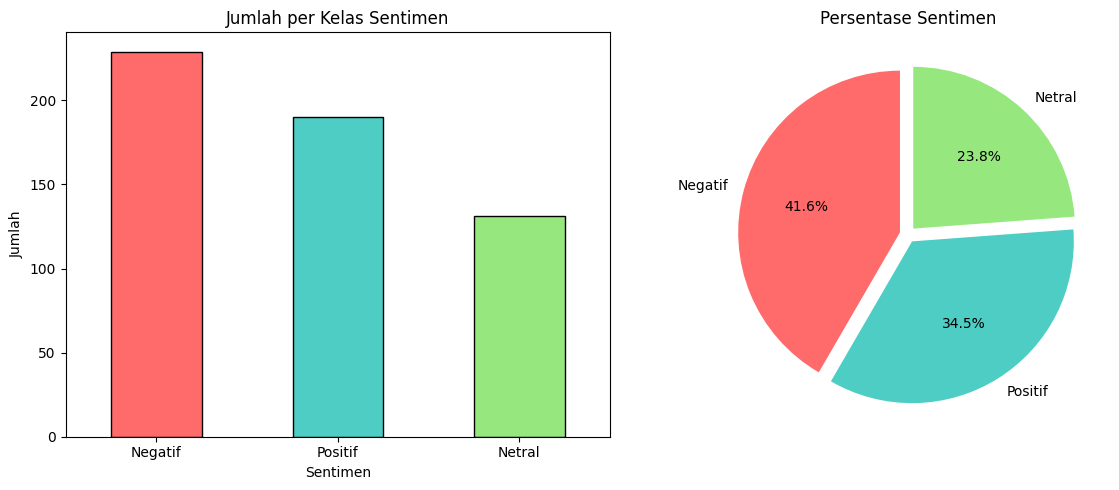

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df_new['sentiment'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#95e77e']
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Jumlah per Kelas Sentimen')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors,
            explode=[0.05]*3, startangle=90)
axes[1].set_title('Persentase Sentimen')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# **Split Data & Tokenization**

In [92]:
# Encode label string → angka
label2id = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
id2label = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

df_new['label'] = df_new['sentiment'].map(label2id)

# Split 70% train, 15% val, 15% test
X = df_new['title_clean'].values
y = df_new['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

Train : 385
Val   : 82
Test  : 83


In [93]:
# Load tokenizer IndoBERT base
MODEL_NAME = "indobenchmark/indobert-large-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenisasi semua split
MAX_LEN = 128

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN)
val_encodings   = tokenizer(list(X_val),   truncation=True, padding=True, max_length=MAX_LEN)
test_encodings  = tokenizer(list(X_test),  truncation=True, padding=True, max_length=MAX_LEN)

print("Tokenisasi selesai")
print(f"Contoh token IDs: {train_encodings['input_ids'][0][:10]}")

Tokenisasi selesai
Contoh token IDs: [2, 20964, 5109, 111, 680, 2945, 1711, 64, 70, 271]


In [94]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, y_train)
val_dataset   = SentimentDataset(val_encodings,   y_val)
test_dataset  = SentimentDataset(test_encodings,  y_test)

print(f"Dataset siap: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Dataset siap: train=385, val=82, test=83


# **Fine-Tuning IndoBERT with Weighted Loss**

In [95]:
counts_train = np.bincount(y_train)
weights = 1.0 / counts_train
weights = weights / weights.sum() * len(counts_train)
class_weights = torch.tensor(weights, dtype=torch.float)

print('Class Weights: ')
for i, w in enumerate(class_weights):
    print(f' {id2label[i]} : {w:.4f}')

Class Weights: 
 Negatif : 0.7610
 Netral : 1.3235
 Positif : 0.9155


In [96]:
# metrics during training
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1": f1}

In [97]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print('Model IndoBERT siap di fine-tune.')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-large-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model IndoBERT siap di fine-tune.


In [98]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = CrossEntropyLoss(
            weight = class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [99]:
# Konfigurasi training
training_args = TrainingArguments(
    output_dir='./indobert-ihsg-finetuned',
    save_total_limit=1,
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    warmup_steps=100,
    lr_scheduler_type='cosine',
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=50,
    report_to='none'
)

# Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Mulai training dengan class weight..")
trainer.train()

Mulai training dengan class weight..


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.139144,0.414634,0.277842
2,No log,1.105645,0.439024,0.313227
3,No log,1.072589,0.487805,0.397290
4,1.099211,1.034568,0.548780,0.523518
5,1.099211,0.964592,0.670732,0.651286
6,1.099211,0.808913,0.682927,0.662385
7,1.099211,0.698670,0.695122,0.681028
8,0.725239,0.626633,0.731707,0.722001
9,0.725239,0.576236,0.792683,0.792569
10,0.725239,0.623754,0.780488,0.763529


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=260, training_loss=0.39702324122190474, metrics={'train_runtime': 338.6962, 'train_samples_per_second': 22.734, 'train_steps_per_second': 0.768, 'total_flos': 266293006102200.0, 'train_loss': 0.39702324122190474, 'epoch': 20.0})

# **Model Evaluation**

In [100]:
# Prediksi pada data test
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)

print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif']))

Classification Report: 
              precision    recall  f1-score   support

     Negatif       0.89      0.89      0.89        35
      Netral       0.68      0.89      0.77        19
     Positif       0.96      0.76      0.85        29

    accuracy                           0.84        83
   macro avg       0.84      0.85      0.83        83
weighted avg       0.86      0.84      0.85        83



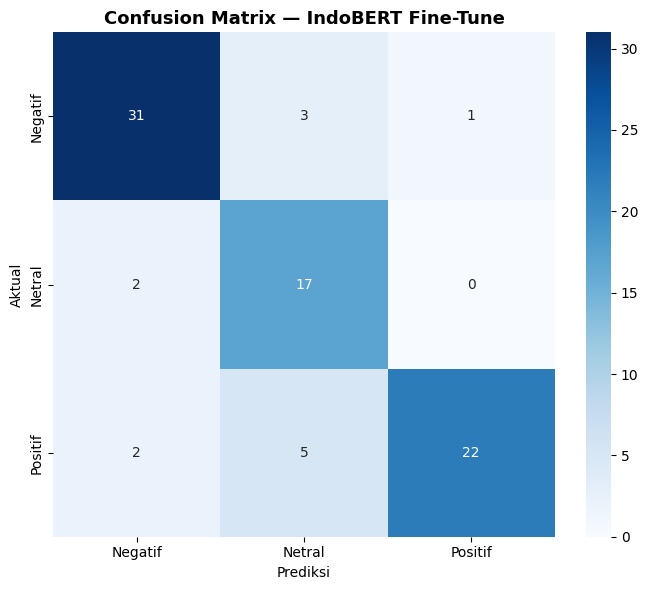

In [101]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix — IndoBERT Fine-Tune', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [102]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1 Macro : {f1:.4f} ({f1*100:.2f}%)")

Accuracy : 0.8434 (84.34%)
F1 Macro : 0.8349 (83.49%)


# Testing

In [103]:
judul = "ihsg meroket lagi"

model.eval()
encoding = tokenizer(judul, truncation=True, padding='max_length', max_length=128, return_tensors='pt')

encoding = {k: v.to(model.device) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**encoding)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred  = torch.argmax(probs, dim=-1).item()

print(f"Judul     : {judul}")
print(f"Sentimen  : {id2label[pred]}")
print(f"Confidence: {probs[0][pred].item():.2%}")

Judul     : ihsg meroket lagi
Sentimen  : Positif
Confidence: 86.13%


In [104]:
judul = "ihsg tertekan reksadana malah ngegas"

model.eval()
encoding = tokenizer(judul, truncation=True, padding='max_length', max_length=128, return_tensors='pt')

encoding = {k: v.to(model.device) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**encoding)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred  = torch.argmax(probs, dim=-1).item()

print(f"Judul     : {judul}")
print(f"Sentimen  : {id2label[pred]}")
print(f"Confidence: {probs[0][pred].item():.2%}")

Judul     : ihsg tertekan reksadana malah ngegas
Sentimen  : Negatif
Confidence: 98.74%


In [107]:
judul = "april jadi bulan krusial ihsg ini tanggal keramat yang harus dicatat"

model.eval()
encoding = tokenizer(judul, truncation=True, padding='max_length', max_length=128, return_tensors='pt')

encoding = {k: v.to(model.device) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**encoding)
    probs = torch.softmax(outputs.logits, dim=-1)
    pred  = torch.argmax(probs, dim=-1).item()

print(f"Judul     : {judul}")
print(f"Sentimen  : {id2label[pred]}")
print(f"Confidence: {probs[0][pred].item():.2%}")

Judul     : april jadi bulan krusial ihsg ini tanggal keramat yang harus dicatat
Sentimen  : Netral
Confidence: 96.77%


In [106]:
# df_new.to_csv('ihsg_sentiment_labeled.csv', index=False)